# 🚢 Exploratory Data Analysis (EDA) on the Titanic Dataset

## 📌 Project Overview
This project performs Exploratory Data Analysis (EDA) on the Titanic dataset to understand its structure, identify patterns, detect missing values and outliers, and extract meaningful insights using statistical analysis and data visualization.

## 🎯 Objectives
- Understand the dataset structure
- Perform data cleaning and preprocessing
- Analyze numerical and categorical features
- Visualize distributions and relationships
- Generate an automated HTML profiling report
- Summarize key insights

## 🛠️ Technologies Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- fg-data-profiling

---

In [1]:
!pip install -q pandas numpy matplotlib seaborn fg-data-profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.3/400.3 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 2.0 MB/s eta 0:00:00


In [3]:
# ==========================
# Import Required Libraries
# ==========================

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Automated Data Profiling
from data_profiling import ProfileReport

# Notebook Settings
%matplotlib inline
sns.set_style("whitegrid")

In [4]:
from google.colab import files

uploaded = files.upload()

Saving Titanic-Dataset.csv to Titanic-Dataset.csv


In [5]:
# Load the dataset
df = pd.read_csv("Titanic-Dataset.csv")

In [6]:
# Display first five rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# 📊 Data Overview

Before performing any analysis, it is important to understand the structure of the dataset. This includes examining its dimensions, data types, summary statistics, and identifying any missing or duplicate values.

In [17]:
# Dataset Shape

print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

df.shape

Rows: 891
Columns: 12


(891, 12)

In [18]:
# First five rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [19]:
# Last five rows
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [20]:
# Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [21]:
# Summary Statistics

df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [22]:
df.describe(include='object')

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Dooley, Mr. Patrick",male,347082,G6,S
freq,1,577,7,4,644


In [23]:
# Missing Values
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum()/len(df))*100
})

missing.sort_values(by="Missing Values", ascending=False)

,Missing Values,Percentage
Cabin,687,77.104377
Age,177,19.865320
Embarked,2,0.224467
PassengerId,0,0.000000
Name,0,0.000000
Pclass,0,0.000000
Survived,0,0.000000
Sex,0,0.000000
Parch,0,0.000000
SibSp,0,0.000000


In [24]:
# Duplicate Rows

duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


In [25]:
# Unique values in each column

df.nunique()

,0
PassengerId,891
Survived,2
Pclass,3
Name,891
Sex,2
Age,88
SibSp,7
Parch,7
Ticket,681
Fare,248


# 📊 Data Visualization

Data visualization helps identify patterns, trends, relationships, and potential anomalies in the dataset using graphical representations.

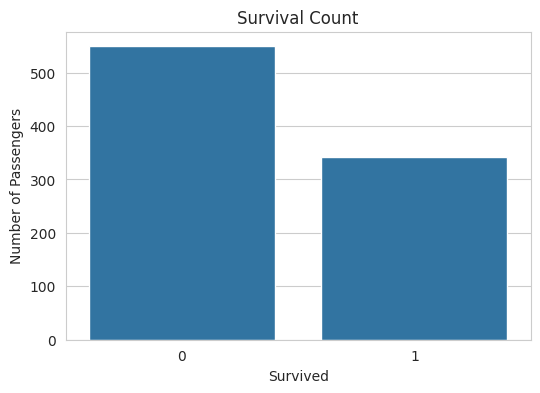

In [26]:
#Survival Distribution
plt.figure(figsize=(6,4))

sns.countplot(x='Survived', data=df)

plt.title("Survival Count")
plt.xlabel("Survived")
plt.ylabel("Number of Passengers")

plt.show()

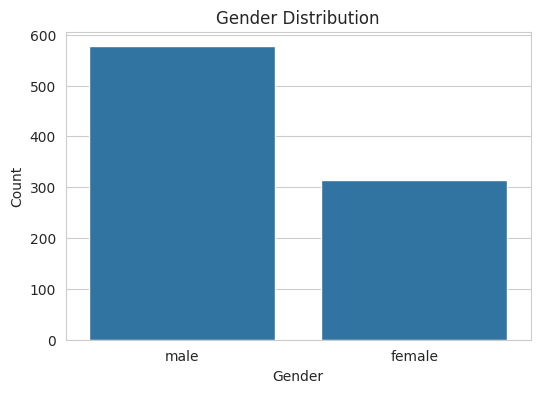

In [27]:
#Gender Distribution
plt.figure(figsize=(6,4))

sns.countplot(x='Sex', data=df)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

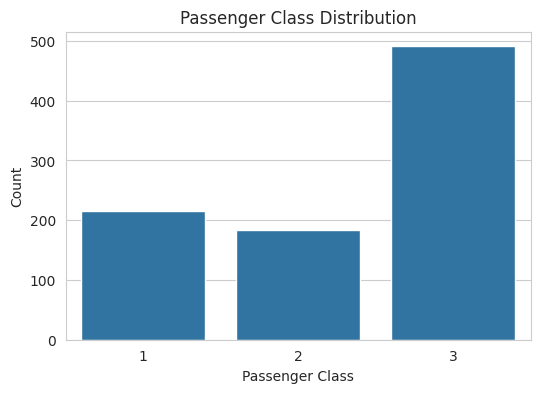

In [28]:
#Passenger Class Distribution
plt.figure(figsize=(6,4))

sns.countplot(x='Pclass', data=df)

plt.title("Passenger Class Distribution")
plt.xlabel("Passenger Class")
plt.ylabel("Count")

plt.show()

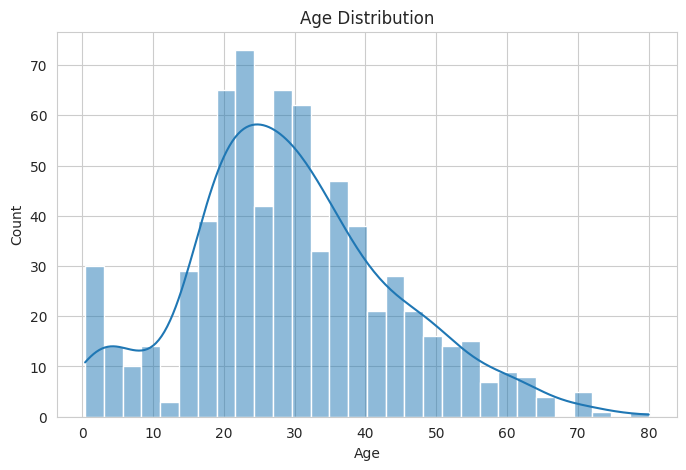

In [29]:
#Age Distribution
plt.figure(figsize=(8,5))

sns.histplot(df['Age'], bins=30, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")

plt.show()

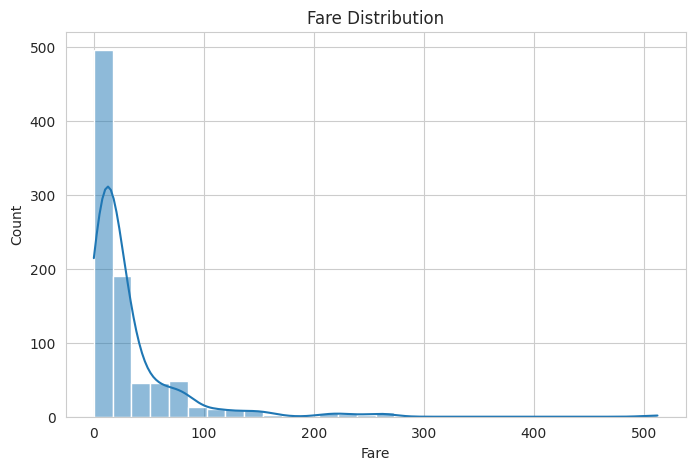

In [30]:
#Fare Distribution
plt.figure(figsize=(8,5))

sns.histplot(df['Fare'], bins=30, kde=True)

plt.title("Fare Distribution")
plt.xlabel("Fare")

plt.show()

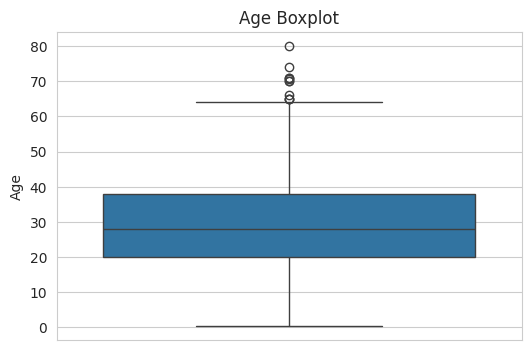

In [31]:
#Boxplot (Age)
plt.figure(figsize=(6,4))

sns.boxplot(y=df['Age'])

plt.title("Age Boxplot")

plt.show()

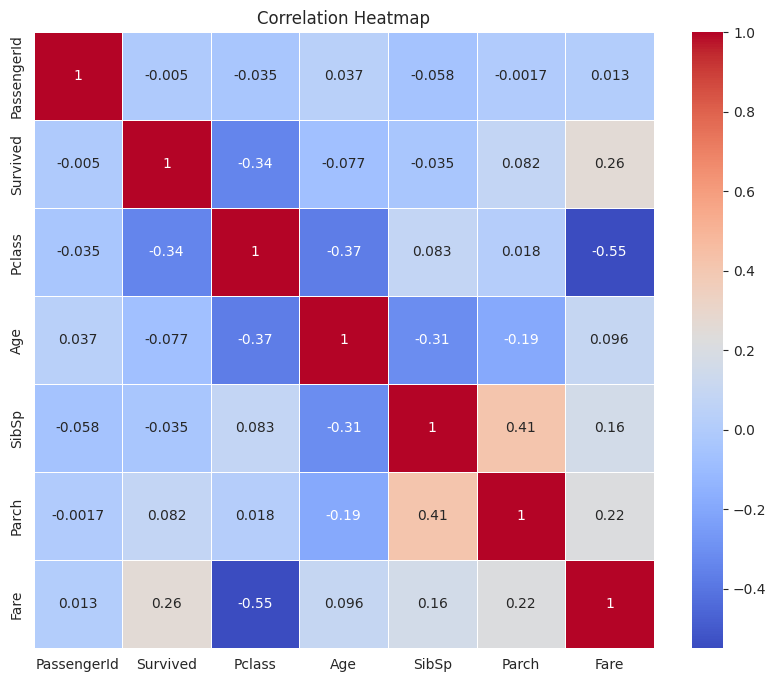

In [32]:
#Correlation Heatmap
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

# 📑 Automated Data Profiling Report

Automated data profiling provides a comprehensive summary of the dataset by analyzing its structure, data types, missing values, statistical distributions, correlations, duplicate records, and potential data quality issues. This report helps in quickly understanding the dataset and identifying areas that may require further investigation or preprocessing.

## 🎯 Objective

Generate an interactive HTML report using the **fg-data-profiling** library for comprehensive exploratory data analysis.

In [33]:
# Generate Automated Data Profiling Report

profile = ProfileReport(
    df,
    title="Titanic Dataset Profiling Report",
    explorative=True
)

profile.to_file("report.html")

print("✅ HTML profiling report generated successfully!")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 12/12 [00:00<00:00, 48.52it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

✅ HTML profiling report generated successfully!


In [34]:
# Download the HTML report

from google.colab import files

files.download("report.html")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# 💡 Key Insights

Based on the exploratory data analysis and the automated profiling report, the following insights were observed from the Titanic dataset:

In [35]:
# Key Insights

insights = [
    "The dataset contains 891 passenger records with 12 features.",
    "The Age column contains missing values, while the Cabin column has a significant number of missing entries.",
    "Most passengers traveled in Third Class (Pclass = 3).",
    "Male passengers outnumber female passengers in the dataset.",
    "A larger proportion of female passengers survived compared to male passengers.",
    "The Fare distribution is positively skewed with several high-value outliers.",
    "No duplicate rows were found in the dataset.",
    "The automated profiling report provides detailed statistics, correlations, distributions, and data quality analysis."
]

for i, insight in enumerate(insights, 1):
    print(f"{i}. {insight}")

1. The dataset contains 891 passenger records with 12 features.
2. The Age column contains missing values, while the Cabin column has a significant number of missing entries.
3. Most passengers traveled in Third Class (Pclass = 3).
4. Male passengers outnumber female passengers in the dataset.
5. A larger proportion of female passengers survived compared to male passengers.
6. The Fare distribution is positively skewed with several high-value outliers.
7. No duplicate rows were found in the dataset.
8. The automated profiling report provides detailed statistics, correlations, distributions, and data quality analysis.


# 📝 Conclusion

This Exploratory Data Analysis (EDA) project successfully examined the Titanic dataset using statistical summaries, data visualization techniques, and automated data profiling.

The analysis provided valuable insights into passenger demographics, survival patterns, missing values, and feature distributions. Additionally, an interactive HTML profiling report was generated using **fg-data-profiling**, enabling a comprehensive understanding of the dataset.

This project demonstrates the importance of EDA as the first step in any data science workflow, helping identify patterns, data quality issues, and opportunities for further analysis or predictive modeling.